In [6]:
import pandas as pd
import os

dataframes = {}

json_files = [
    '/content/Firms_with_Female_Ownership.json',
    '/content/Persistence_to_Grade_5_Female.json',
    '/content/Women_Justify_Beating_Wife.json',
    '/content/Women_in_Ministerial_Positions.json',
    '/content/Women_in_Parliament_Seats.json',
    '/content/Households_with_Female_Head.json',
    '/content/Women_Never_Sought_Help_for_Violence.json',
    '/content/Fertility_Rate.json',
    '/content/Women_in_Senior_Management.json',
    '/content/Women_Subjected_to_Violence_Last_12_Months.json',
    '/content/Women_Married_by_Age_15.json',
    '/content/Women_with_Demand_for_Family_Planning.json',
    '/content/Female_Labor_Force_Participation.json'
]

for file_path in json_files:
    # Extract the base name of the file without the extension
    base_name = os.path.splitext(os.path.basename(file_path))[0]
    # Load the JSON file into a pandas DataFrame
    df = pd.read_json(file_path)
    # Store the DataFrame in the dataframes dictionary
    dataframes[base_name] = df

print("Successfully loaded the following dataframes:")
for df_name in dataframes.keys():
    print(f"- {df_name}")

Successfully loaded the following dataframes:
- Firms_with_Female_Ownership
- Persistence_to_Grade_5_Female
- Women_Justify_Beating_Wife
- Women_in_Ministerial_Positions
- Women_in_Parliament_Seats
- Households_with_Female_Head
- Women_Never_Sought_Help_for_Violence
- Fertility_Rate
- Women_in_Senior_Management
- Women_Subjected_to_Violence_Last_12_Months
- Women_Married_by_Age_15
- Women_with_Demand_for_Family_Planning
- Female_Labor_Force_Participation


In [7]:
for df_name, df in dataframes.items():
    print(f"\n--- Exploring DataFrame: {df_name} ---")
    print("\nHead of DataFrame:")
    print(df.head())
    print("\nInfo of DataFrame:")
    df.info()
    print("\nDescription of DataFrame (numerical columns):")
    print(df.describe())


--- Exploring DataFrame: Firms_with_Female_Ownership ---

Head of DataFrame:
   count                                              value
0    411  {'OBS_VALUE': '33.3', 'TIME_FORMAT': None, 'UN...
1    411  {'OBS_VALUE': '9', 'TIME_FORMAT': None, 'UNIT_...
2    411  {'OBS_VALUE': '12.8', 'TIME_FORMAT': None, 'UN...
3    411  {'OBS_VALUE': '11.5', 'TIME_FORMAT': None, 'UN...
4    411  {'OBS_VALUE': '14.6', 'TIME_FORMAT': None, 'UN...

Info of DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   count   411 non-null    int64 
 1   value   411 non-null    object
dtypes: int64(1), object(1)
memory usage: 6.6+ KB

Description of DataFrame (numerical columns):
       count
count  411.0
mean   411.0
std      0.0
min    411.0
25%    411.0
50%    411.0
75%    411.0
max    411.0

--- Exploring DataFrame: Persistence_to_Grade_5_Female ---

Head of DataFrame:


In [ ]:
import pandas as pd

normalized_dataframes = {}

for df_name, df in dataframes.items():
    print(f"\n--- Normalizing DataFrame: {df_name} ---")
    # Normalize the 'value' column which contains nested JSON/dictionary
    normalized_df = pd.json_normalize(df['value'])

    # Concatenate the normalized columns with the original DataFrame (excluding the original 'value' column)
    # If the original DataFrame has other useful columns besides 'count' and 'value', include them appropriately.
    # For these specific dataframes, 'count' seems to be a redundant column, but keeping it for now.
    # Let's assume the useful data is primarily in the 'value' column for now.
    final_df = pd.concat([df.drop(columns=['value']), normalized_df], axis=1)
    normalized_dataframes[df_name] = final_df

    print("Normalized DataFrame Head:")
    print(final_df.head())
    print("Normalized DataFrame Info:")
    final_df.info()

# Update the original dataframes dictionary with the normalized dataframes
dataframes = normalized_dataframes

In [ ]:
for df_name, df in dataframes.items():
    print(f"\n--- Further Exploring Normalized DataFrame: {df_name} ---")
    # Convert OBS_VALUE to numeric, coercing errors to NaN
    df['OBS_VALUE'] = pd.to_numeric(df['OBS_VALUE'], errors='coerce')

    print("\nHead of Normalized DataFrame (after numeric conversion):")
    print(df.head())
    print("\nInfo of Normalized DataFrame:")
    df.info()
    print("\nDescription of Normalized DataFrame (numerical columns):")
    print(df.describe())

# Identify common columns across all normalized DataFrames
if dataframes:
    first_df_columns = set(list(dataframes.values())[0].columns)
    common_columns = first_df_columns.copy()
    for df_name, df in dataframes.items():
        common_columns = common_columns.intersection(set(df.columns))
    print(f"\n--- Common columns across all DataFrames: ---")
    print(sorted(list(common_columns)))
else:
    print("No DataFrames to process.")

### Proposed Research Hypothesis:
"There is a negative correlation between the proportion of women in parliamentary seats and ministerial positions and the percentage of women who justify wife-beating across different countries and time periods."

**Reasoning for this hypothesis:**
This hypothesis links political empowerment (women's representation in government) with a key social indicator of gender inequality (acceptance of domestic violence). The assumption is that increased political influence by women may lead to policy changes, cultural shifts, or greater awareness that reduces the justification of violence against women. This hypothesis is testable using the `Women_in_Parliament_Seats`, `Women_in_Ministerial_Positions`, and `Women_Justify_Beating_Wife` datasets, as they all share `REF_AREA` (country/region) and `TIME_PERIOD` columns, allowing for comparative analysis.

## Summary:

### Q&A
**Research Hypothesis:**
There is a negative correlation between the proportion of women in parliamentary seats and ministerial positions and the percentage of women who justify wife-beating across different countries and time periods.

### Data Analysis Key Findings
*   All 13 provided JSON files were successfully loaded into separate pandas DataFrames, including `Firms_with_Female_Ownership`, `Persistence_to_Grade_5_Female`, `Women_Justify_Beating_Wife`, `Women_in_Ministerial_Positions`, `Women_in_Parliament_Seats`, `Households_with_Female_Head`, `Women_Never_Sought_Help_for_Violence`, `Fertility_Rate`, `Women_in_Senior_Management`, `Women_Subjected_to_Violence_Last_12_Months`, `Women_Married_by_Age_15`, `Women_with_Demand_for_Family_Planning`, and `Female_Labor_Force_Participation`.
*   Initial data exploration revealed that each DataFrame contained a nested 'value' column. This column was successfully normalized, expanding into various detailed columns such as `OBS_VALUE`, `REF_AREA` (country/region), `TIME_PERIOD` (year), and `INDICATOR`.
*   The `OBS_VALUE` column, which contains the core numerical data for each indicator, was successfully converted from an object data type to a `float64` numeric type, enabling quantitative analysis.
*   Common columns across all normalized DataFrames were identified, including `REF_AREA`, `TIME_PERIOD`, and `OBS_VALUE`, which are crucial for cross-dataset analysis and merging.



In [9]:
import pandas as pd

# 1. Extract the relevant DataFrames
df_parliament = dataframes['Women_in_Parliament_Seats'].copy()
df_ministerial = dataframes['Women_in_Ministerial_Positions'].copy()
df_justify = dataframes['Women_Justify_Beating_Wife'].copy()

# 2. Select only 'REF_AREA', 'TIME_PERIOD', and 'OBS_VALUE' columns and rename 'OBS_VALUE'
df_parliament_selected = df_parliament[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_parliament_selected = df_parliament_selected.rename(columns={'OBS_VALUE': 'Parliament_Seats_Percentage'})

df_ministerial_selected = df_ministerial[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_ministerial_selected = df_ministerial_selected.rename(columns={'OBS_VALUE': 'Ministerial_Positions_Percentage'})

df_justify_selected = df_justify[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_justify_selected = df_justify_selected.rename(columns={'OBS_VALUE': 'Justify_Beating_Wife_Percentage'})

# 4. Perform an inner merge between Parliament and Ministerial DataFrames
merged_df = pd.merge(
    df_parliament_selected,
    df_ministerial_selected,
    on=['REF_AREA', 'TIME_PERIOD'],
    how='inner'
)

# 5. Perform another inner merge with the Justify Beating Wife DataFrame
hypothesis_df = pd.merge(
    merged_df,
    df_justify_selected,
    on=['REF_AREA', 'TIME_PERIOD'],
    how='inner'
)

# 6. Print the first few rows and the info of hypothesis_df
print("Head of the merged DataFrame (hypothesis_df):")
print(hypothesis_df.head())

print("\nInfo of the merged DataFrame (hypothesis_df):")
hypothesis_df.info()


KeyError: "None of [Index(['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE'], dtype='object')] are in the [columns]"

In [10]:
# 1. Extract the relevant DataFrames from the correctly normalized dictionary
df_parliament = normalized_dataframes['Women_in_Parliament_Seats'].copy()
df_ministerial = normalized_dataframes['Women_in_Ministerial_Positions'].copy()
df_justify = normalized_dataframes['Women_Justify_Beating_Wife'].copy()

# 2. Select only 'REF_AREA', 'TIME_PERIOD', and 'OBS_VALUE' columns and rename 'OBS_VALUE'
df_parliament_selected = df_parliament[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_parliament_selected = df_parliament_selected.rename(columns={'OBS_VALUE': 'Parliament_Seats_Percentage'})

df_ministerial_selected = df_ministerial[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_ministerial_selected = df_ministerial_selected.rename(columns={'OBS_VALUE': 'Ministerial_Positions_Percentage'})

df_justify_selected = df_justify[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_justify_selected = df_justify_selected.rename(columns={'OBS_VALUE': 'Justify_Beating_Wife_Percentage'})

# 4. Perform an inner merge between Parliament and Ministerial DataFrames
merged_df = pd.merge(
    df_parliament_selected,
    df_ministerial_selected,
    on=['REF_AREA', 'TIME_PERIOD'],
    how='inner'
)

# 5. Perform another inner merge with the Justify Beating Wife DataFrame
hypothesis_df = pd.merge(
    merged_df,
    df_justify_selected,
    on=['REF_AREA', 'TIME_PERIOD'],
    how='inner'
)

# 6. Print the first few rows and the info of hypothesis_df
print("Head of the merged DataFrame (hypothesis_df):")
print(hypothesis_df.head())

print("\nInfo of the merged DataFrame (hypothesis_df):")
hypothesis_df.info()


Head of the merged DataFrame (hypothesis_df):
Empty DataFrame
Columns: [REF_AREA, TIME_PERIOD, Parliament_Seats_Percentage, Ministerial_Positions_Percentage, Justify_Beating_Wife_Percentage]
Index: []

Info of the merged DataFrame (hypothesis_df):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   REF_AREA                          0 non-null      object 
 1   TIME_PERIOD                       0 non-null      object 
 2   Parliament_Seats_Percentage       0 non-null      float64
 3   Ministerial_Positions_Percentage  0 non-null      float64
 4   Justify_Beating_Wife_Percentage   0 non-null      float64
dtypes: float64(3), object(2)
memory usage: 132.0+ bytes


In [11]:
print("\nUnique REF_AREA in df_parliament_selected:")
print(df_parliament_selected['REF_AREA'].unique())
print("\nUnique TIME_PERIOD in df_parliament_selected:")
print(df_parliament_selected['TIME_PERIOD'].unique())

print("\nUnique REF_AREA in df_ministerial_selected:")
print(df_ministerial_selected['REF_AREA'].unique())
print("\nUnique TIME_PERIOD in df_ministerial_selected:")
print(df_ministerial_selected['TIME_PERIOD'].unique())

print("\nUnique REF_AREA in df_justify_selected:")
print(df_justify_selected['REF_AREA'].unique())
print("\nUnique TIME_PERIOD in df_justify_selected:")
print(df_justify_selected['TIME_PERIOD'].unique())


Unique REF_AREA in df_parliament_selected:
['AFE' 'ARB' 'CSS' 'CEB' 'EAR' 'EMU' 'ECS' 'ECA' 'TEC' 'EUU' 'HPC' 'HIC'
 'IBD' 'IBT' 'IDB' 'IDX' 'IDA' 'LCN' 'LAC' 'TLA' 'LDC' 'LMC' 'MEA' 'MNA'
 'TMN' 'NAC' 'OED' 'OSS' 'PSS' 'PST' 'SST' 'SAS' 'TSA' 'SSF' 'TSS' 'WLD'
 'DZA' 'AND' 'AGO' 'ATG' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BHS' 'BGD' 'BRB'
 'BEL' 'BLZ' 'BEN' 'BTN' 'BWA' 'BRA' 'BGR' 'BFA' 'CPV' 'KHM' 'CMR' 'CAN'
 'CAF' 'TCD' 'CHL' 'COL' 'COM' 'CRI' 'CIV' 'HRV' 'CUB' 'CYP' 'CZE' 'DNK'
 'DMA' 'DOM' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI' 'EST' 'SWZ' 'ETH' 'FJI' 'FIN'
 'FRA' 'GAB' 'GMB' 'GEO' 'DEU' 'GHA' 'GRC' 'GRD' 'GTM' 'GIN' 'GNB' 'HTI'
 'HUN' 'ISL' 'IND' 'IDN' 'IRN' 'IRQ' 'IRL' 'ISR' 'ITA' 'JAM' 'JPN' 'JOR'
 'KAZ' 'KEN' 'KIR' 'PRK' 'KOR' 'KWT' 'KGZ' 'LVA' 'LBN' 'LSO' 'LIE' 'LTU'
 'LUX' 'MDG' 'MWI' 'MYS' 'MDV' 'MLI' 'MLT' 'MRT' 'MUS' 'MEX' 'FSM' 'MDA'
 'MCO' 'MNG' 'MAR' 'MOZ' 'NAM' 'NPL' 'NLD' 'NZL' 'NIC' 'NER' 'MKD' 'NOR'
 'PAK' 'PLW' 'PAN' 'PNG' 'PRY' 'PER' 'PHL' 'POL' 'PRT' 'ROU' 'RUS' 'RWA'
 'WSM' 

In [12]:
import pandas as pd

# 1. Extract the relevant DataFrames from the correctly normalized dictionary
df_parliament = normalized_dataframes['Women_in_Parliament_Seats'].copy()
df_ministerial = normalized_dataframes['Women_in_Ministerial_Positions'].copy()
df_justify = normalized_dataframes['Women_Justify_Beating_Wife'].copy()

# 2. Select only 'REF_AREA', 'TIME_PERIOD', and 'OBS_VALUE' columns and rename 'OBS_VALUE'
df_parliament_selected = df_parliament[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_parliament_selected = df_parliament_selected.rename(columns={'OBS_VALUE': 'Parliament_Seats_Percentage'})

df_ministerial_selected = df_ministerial[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_ministerial_selected = df_ministerial_selected.rename(columns={'OBS_VALUE': 'Ministerial_Positions_Percentage'})

df_justify_selected = df_justify[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_justify_selected = df_justify_selected.rename(columns={'OBS_VALUE': 'Justify_Beating_Wife_Percentage'})

# Aggregate by REF_AREA, calculating the mean of the percentage values
parliament_agg = df_parliament_selected.groupby('REF_AREA')['Parliament_Seats_Percentage'].mean().reset_index()
ministerial_agg = df_ministerial_selected.groupby('REF_AREA')['Ministerial_Positions_Percentage'].mean().reset_index()
justify_agg = df_justify_selected.groupby('REF_AREA')['Justify_Beating_Wife_Percentage'].mean().reset_index()

# Perform an inner merge between aggregated Parliament and Ministerial DataFrames
merged_agg_df = pd.merge(
    parliament_agg,
    ministerial_agg,
    on=['REF_AREA'],
    how='inner'
)

# Perform another inner merge with the aggregated Justify Beating Wife DataFrame
hypothesis_df = pd.merge(
    merged_agg_df,
    justify_agg,
    on=['REF_AREA'],
    how='inner'
)

# Print the first few rows and the info of hypothesis_df
print("Head of the merged DataFrame (hypothesis_df):")
print(hypothesis_df.head())

print("\nInfo of the merged DataFrame (hypothesis_df):")
hypothesis_df.info()

Head of the merged DataFrame (hypothesis_df):
  REF_AREA  Parliament_Seats_Percentage  Ministerial_Positions_Percentage  \
0      AGO                    14.272690                             17.64   
1      ALB                     5.345623                             11.08   
2      ARM                     4.358380                              7.72   
3      BDI                    11.665228                             28.02   
4      BEN                     6.506028                             21.50   

   Justify_Beating_Wife_Percentage  
0                             25.2  
1                              6.8  
2                             10.1  
3                             61.8  
4                             31.8  

Info of the merged DataFrame (hypothesis_df):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  --

## Calculate Correlations

Calculate the Pearson correlation coefficient between the proportion of women in parliamentary seats, the proportion of women in ministerial positions, and the percentage of women who justify wife-beating.


In [13]:
import pandas as pd

# 1. Calculate the Pearson correlation coefficient between 'Parliament_Seats_Percentage' and 'Justify_Beating_Wife_Percentage'
correlation_parliament_justify = hypothesis_df['Parliament_Seats_Percentage'].corr(hypothesis_df['Justify_Beating_Wife_Percentage'])

# 2. Calculate the Pearson correlation coefficient between 'Ministerial_Positions_Percentage' and 'Justify_Beating_Wife_Percentage'
correlation_ministerial_justify = hypothesis_df['Ministerial_Positions_Percentage'].corr(hypothesis_df['Justify_Beating_Wife_Percentage'])

# 3. Print the calculated correlation coefficients
print(f"Pearson Correlation between Women in Parliament Seats and Justify Wife Beating: {correlation_parliament_justify:.4f}")
print(f"Pearson Correlation between Women in Ministerial Positions and Justify Wife Beating: {correlation_ministerial_justify:.4f}")

Pearson Correlation between Women in Parliament Seats and Justify Wife Beating: -0.1331
Pearson Correlation between Women in Ministerial Positions and Justify Wife Beating: -0.1395


## Visualize Correlations with Scatter Plots

Generate scatter plots to visually represent the relationships identified in the hypothesis. Plot 'Women in Parliament Seats' vs. 'Women Justify Beating Wife' and 'Women in Ministerial Positions' vs. 'Women Justify Beating Wife'. Add appropriate labels, titles, and a regression line to each plot to illustrate the trends. Ensure legends are clear.


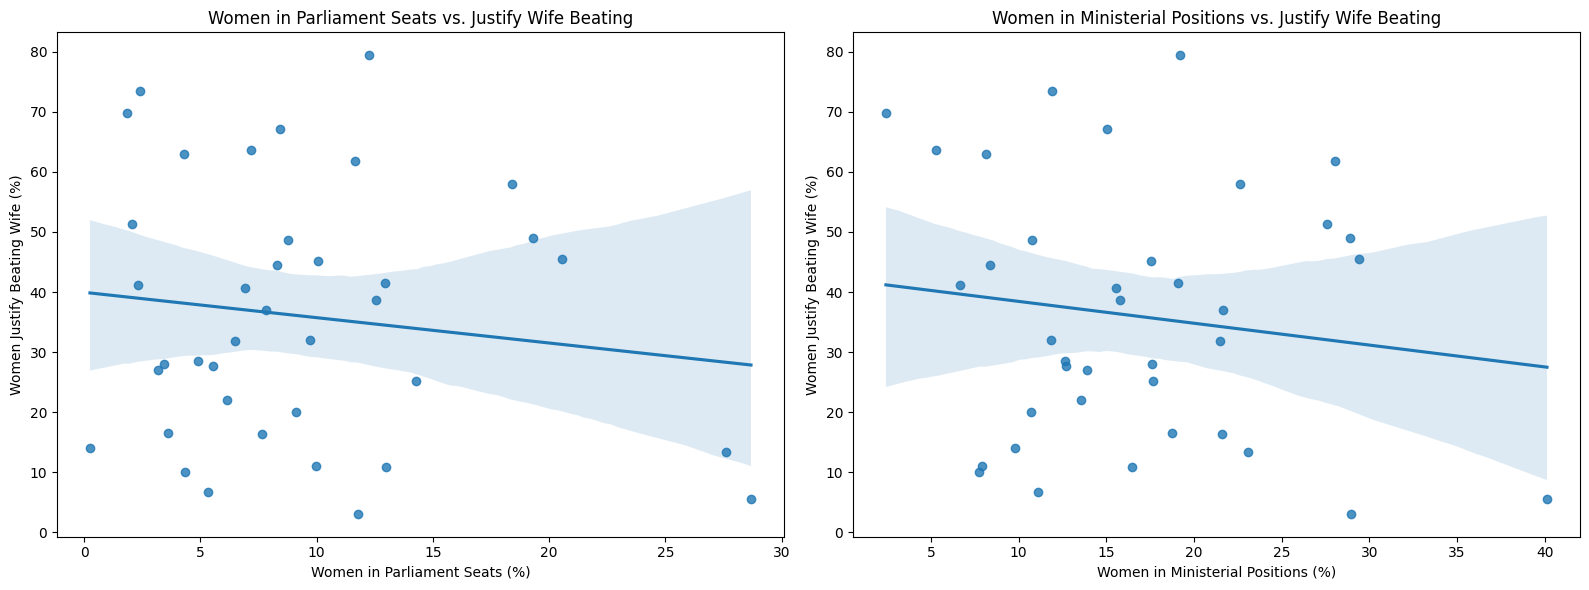

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Women in Parliament Seats vs. Women Justify Beating Wife
sns.regplot(x='Parliament_Seats_Percentage', y='Justify_Beating_Wife_Percentage', data=hypothesis_df, ax=axes[0])
axes[0].set_title('Women in Parliament Seats vs. Justify Wife Beating')
axes[0].set_xlabel('Women in Parliament Seats (%)')
axes[0].set_ylabel('Women Justify Beating Wife (%)')

# Second subplot: Women in Ministerial Positions vs. Women Justify Beating Wife
sns.regplot(x='Ministerial_Positions_Percentage', y='Justify_Beating_Wife_Percentage', data=hypothesis_df, ax=axes[1])
axes[1].set_title('Women in Ministerial Positions vs. Justify Wife Beating')
axes[1].set_xlabel('Women in Ministerial Positions (%)')
axes[1].set_ylabel('Women Justify Beating Wife (%)')

# Adjust layout and display plots
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Correlation between Political Representation and Justification of Wife Beating**:
    *   The Pearson correlation coefficient between 'Parliament\_Seats\_Percentage' and 'Justify\_Beating\_Wife\_Percentage' is **-0.1331**, indicating a very weak negative linear relationship.
    *   The Pearson correlation coefficient between 'Ministerial\_Positions\_Percentage' and 'Justify\_Beating\_Wife\_Percentage' is **-0.1395**, also indicating a very weak negative linear relationship.
*   **Visual Representation**: Scatter plots with regression lines were successfully generated, visually confirming these very weak negative trends.

